In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import argparse
import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [2]:
output_folder="../PhysiCell/results/mechanics_pushing/"
# "cells_position_time.csv"
# Read the CSV file
df = pd.read_csv(output_folder + "cells_position_time.csv")

# Compute the absolute difference in 'x' positions between cells with id 0 and 1
x0 = df[df['id'] == 0]['x'].reset_index(drop=True)
x1 = df[df['id'] == 1]['x'].reset_index(drop=True)
pc_dist_dt = pd.DataFrame()
pc_dist_dt["dx"] = abs(x0 - x1)

# Add the time steps (assuming 'dt' repeats per ID)
dt = df[df['id'] == 0]['dt'].reset_index(drop=True)
pc_dist_dt["dt"] = dt

pc_dist_dt


,dx,dt
0,30.000000,0.0
1,27.000000,0.1
2,25.000000,0.2
3,23.000000,0.3
4,21.000000,0.4
...,...,...
96,9.992042,9.6
97,9.991721,9.7
98,9.991400,9.8
99,9.991080,9.9


In [ ]:
# XXX check that this are the latest results
file = "../Biodynamo/unit_test_mechanics_pushing/results/positions.csv"
bd_dist = pd.read_csv(file,index_col=0,header = None,sep='\t|,',engine='python').rename(columns={1: "x1", 4: "x2"})
bd_dist


,x1,2,3,x2,5,6
0,,,,,,
0,-14,0,0,14,0,0
1,-13,0,1,13,0,0
2,-12,0,2,12,0,0
3,-11,0,3,11,0,0
4,-10,0,4,10,0,0
...,...,...,...,...,...,...
95,-6,0,95,6,0,0
96,-6,0,96,6,0,0
97,-6,0,97,6,0,0


In [4]:
new_row = pd.DataFrame([[-15, 0, 0, 15, 0, 0]], columns=bd_dist.columns)
bd_dist = pd.concat([new_row, bd_dist], ignore_index=True)
bd_dist


,x1,2,3,x2,5,6
0,-15,0,0,15,0,0
1,-14,0,0,14,0,0
2,-13,0,1,13,0,0
3,-12,0,2,12,0,0
4,-11,0,3,11,0,0
...,...,...,...,...,...,...
96,-6,0,95,6,0,0
97,-6,0,96,6,0,0
98,-6,0,97,6,0,0
99,-6,0,98,6,0,0


In [5]:
bd_dist['dx'] = abs(bd_dist["x1"] - bd_dist["x2"])
bd_dist['dt'] = bd_dist.index * 0.1
bd_dist


,x1,2,3,x2,5,6,dx,dt
0,-15,0,0,15,0,0,30,0.0
1,-14,0,0,14,0,0,28,0.1
2,-13,0,1,13,0,0,26,0.2
3,-12,0,2,12,0,0,24,0.3
4,-11,0,3,11,0,0,22,0.4
...,...,...,...,...,...,...,...,...
96,-6,0,95,6,0,0,12,9.6
97,-6,0,96,6,0,0,12,9.7
98,-6,0,97,6,0,0,12,9.8
99,-6,0,98,6,0,0,12,9.9


In [49]:
file = "../Tisim/unit_test_mechanics_pushing/mechanical pushing.csv"
ts_dist = pd.read_csv(file,index_col=None,header=0,names=['time','dx'])
ts_dist


,time,dx
0,0.0,30.0000
1,0.1,28.0000
2,0.2,26.0000
3,0.3,24.0000
4,0.4,22.0000
...,...,...
96,9.6,3.2168
97,9.7,3.2168
98,9.8,3.2168
99,9.9,3.2168


In [45]:
# XXX unclear the units of time
file = "../Chaste/unit_test_mechanics_pushing/results/results.viznodelocations"
ch_dist = pd.read_csv(file,header = None,sep='\t| ',index_col=0,engine='python')
ch_dist['dx'] = abs(ch_dist[4] - ch_dist[1])*10
# ch_dist['dt'] = [x for x in np.arange(0,10.01,0.1)]
# ch_dist.index = ch_dist.index*1000
ch_dist['dt'] = ch_dist.index*60
# ch_dist.index = ch_dist.index*100
ch_dist


,1,2,3,4,5,6,dx,dt
0,,,,,,,,
0.000000,0.00000,0,0,3.00000,0,0,30.0000,0.000000
0.000167,0.01000,0,0,2.99000,0,0,29.8000,0.010000
0.000333,0.02000,0,0,2.98000,0,0,29.6000,0.020000
0.000500,0.03000,0,0,2.97000,0,0,29.4000,0.030000
0.000667,0.04000,0,0,2.96000,0,0,29.2000,0.040000
...,...,...,...,...,...,...,...,...
0.082667,1.00109,0,0,1.99891,0,0,9.9782,4.960002
0.082833,1.00108,0,0,1.99892,0,0,9.9784,4.969998
0.083000,1.00107,0,0,1.99893,0,0,9.9786,4.980000


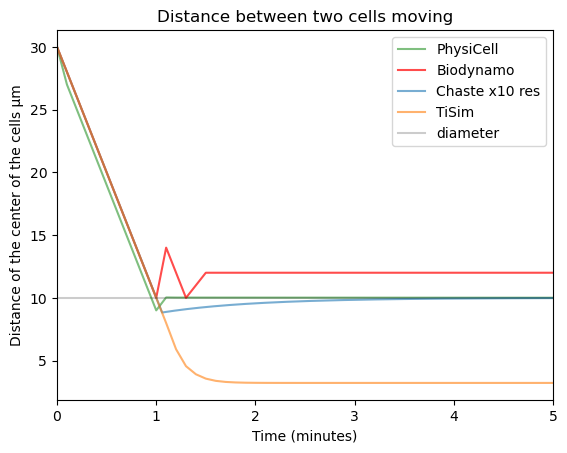

In [ ]:
plt.plot(pc_dist_dt['dt'],pc_dist_dt['dx'],label="PhysiCell", color= 'green',alpha = 0.5)
# plt.plot(pc_dist_dt['dt'],pc_dist_dt['dx'],label="PC Randy", color= 'purple',alpha = 0.5)
plt.plot(bd_dist['dt'],bd_dist['dx'],label="Biodynamo",color= 'red',alpha = 0.7)
plt.plot(ch_dist['dt'],ch_dist['dx'],label="Chaste x10 res",alpha = 0.6)
plt.plot(ts_dist["time"],ts_dist['dx'],label="TiSim",alpha = 0.6)
# plt.plot(range(0, 11) ,  [10] * len(range(0, 11)), label='diameter', color='black',alpha=0.2)
# plt.xticks(np.arange(0, 11, step=1))
plt.plot(range(0, 6) ,  [10] * len(range(0, 6)), label='diameter', color='black',alpha=0.2)
plt.xlim(0, 5)
plt.xticks(np.arange(0, 6, step=1))
plt.ylabel("Distance of the center of the cells μm")
plt.xlabel("Time (minutes)")
plt.legend()
plt.title("Distance between two cells moving")
plt.savefig("./mechanics_movement.png",dpi=200)
plt.show()